# 03 — RAPM: Regularized Adjusted Plus-Minus

One row per **stint** — matches are segmented at substitutions, red cards, *and
goals*, so every stint also has a fixed score state. The response is the stint's
goal differential (home − away), scaled to per-90 and weighted by stint duration.
Each qualified player is a column: **+1** on the pitch for the home side, **−1**
for the away side. Players under 900 career minutes pool into a single
*replacement* column — so coefficients read as **goals added per 90 over a
replacement-level player**, controlling for the other 21 players on the pitch.
Extra controls: an unpenalized intercept (home advantage), a man-count
differential (red cards), score-state dummies (leading/trailing by 1 or 2+),
and match-phase dummies (30–60', 60'+). The fitted control values are sanity
checks the model recovers from data: leading teams generate less, trailing
teams push, home advantage lands near the league's true value.

Ridge regularization handles the massive collinearity (teammates share pitch
time); λ is chosen by cross-validation with folds **grouped by match** so no
match leaks across the train/test split.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from plimpact.config import load_config
from plimpact.validate import load_tables

cfg = load_config()
tables = load_tables(cfg)
matches, appearances, shots, stints = (
    tables["matches"], tables["appearances"], tables["shots"], tables["stints"]
)
pd.set_option("display.width", 120)

In [2]:
from plimpact import rapm

design = rapm.build_design(cfg, appearances, stints)
print(f"{design.X.shape[0]} stints x {design.X.shape[1]} columns "
      f"({len(design.columns) - 2} qualified players)")
print(f"design sparsity: {design.X.nnz / (design.X.shape[0] * design.X.shape[1]):.3%} non-zero")

10315 stints x 597 columns (595 qualified players)
design sparsity: 3.851% non-zero


{'lambda': 6400.0,
 'home_advantage': 0.3248500353044993,
 'man_diff_coef': 0.7006589653027426,
 'replacement_coef': -0.2896745564783345,
 'controls': {'lead1': -0.4394772717162655,
  'lead2': -0.20377859210177535,
  'trail1': 0.2510450438732597,
  'trail2': 0.015978347668849775,
  'mid': -0.14478126831467833,
  'late': -0.010257553281077476}}

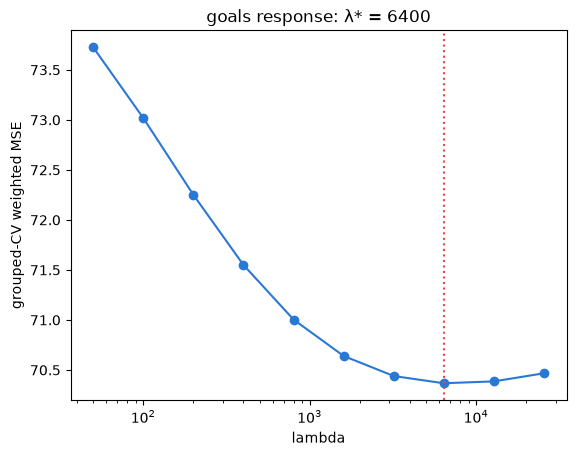

In [3]:
import json
cv = pd.read_parquet(cfg.processed_dir / "cv_curves.parquet")
meta = json.load(open(cfg.processed_dir / "model_meta.json"))
g = cv[cv["response"] == "goals"]
ax = g.plot(x="lambda", y="cv_mse", logx=True, marker="o", color="#2a78d6",
            legend=False, grid=False)
best = meta["goals"]["lambda"]
ax.axvline(best, color="#e34948", linestyle=":")
ax.set_ylabel("grouped-CV weighted MSE"); ax.set_title(f"goals response: λ* = {best:g}")
meta["goals"]

The intercept lands near the league's true home advantage (≈ +0.3–0.4 goals/90)
and the man-diff coefficient is positive (an extra man helps) — two built-in
sanity checks the model recovers from data.

In [4]:
ratings = pd.read_parquet(cfg.processed_dir / "ratings.parquet")
cols = ["player", "latest_team", "total_minutes", "rapm_goals",
        "rapm_goals_lo", "rapm_goals_hi", "naive_gd90"]
ratings.sort_values("rapm_goals", ascending=False).head(20)[cols].round(3)

,player,latest_team,total_minutes,rapm_goals,rapm_goals_lo,rapm_goals_hi,naive_gd90
371,William Saliba,Arsenal,9139,0.263,0.191,0.344,1.047
239,Rodri,Manchester City,4564,0.251,0.145,0.352,0.555
559,David Raya,Arsenal,9696,0.222,0.163,0.282,0.253
23,Luis Díaz,Liverpool,5157,0.222,0.094,0.355,0.979
255,Kevin De Bruyne,Manchester City,2953,0.219,0.095,0.327,0.652
286,Gabriel,Arsenal,8229,0.212,0.115,0.311,0.199
577,Josko Gvardiol,Manchester City,7034,0.210,0.098,0.326,0.327
312,Jacob Murphy,Newcastle United,5314,0.202,0.084,0.330,0.746
525,Jéremy Doku,Manchester City,4943,0.199,0.057,0.325,0.484
240,Martin Odegaard,Arsenal,6835,0.196,0.085,0.300,0.262


Reasonable — but goals are rare (~2.8/match), so even three seasons of stints is
a noisy sample and ridge shrinks aggressively (note the large λ*). The next
notebook swaps the response for **expected goals**, which carries far more
signal per stint.